# Week 2 — Automated Data Pipeline
## DOT On-Time Performance Dataset | BTS Marketing Carrier

**Author:** Abishek Singanur Aswan Kumar  
**Dataset:** BTS Marketing Carrier On-Time Performance (Beginning January 2018)  
**Coverage:** January 2024 — December 2025 (24 months, 15.3M flights)  

---

### What this notebook covers

Week 2 built a fully automated data pipeline that downloads, cleans, and stores monthly BTS On-Time Performance data for any given year. This notebook documents and demonstrates the full pipeline end to end, then uses the resulting dataset for a two-year carrier comparison between Southwest Airlines (WN) and American Airlines (AA).

**Pipeline stages:**
1. `pipeline_01_auto_download.py` — Automated BTS download via Selenium (Chrome)
2. `pipeline_02_process.py` — Unzip, select 15 fields, clean, save monthly CSVs
3. `pipeline_03_build_dataset.py` — Combine monthly files into unified dataset
4. `pipeline_04_carrier_comparison.py` — WN vs AA two-year comparison

**15 fields selected:**
FlightDate, Carrier, TailNumber, FlightNumber, Origin, Dest,  
SchedDep, ActualDep, DepDelay, SchedArr, ActualArr, ArrDelay,  
Cancelled, Diverted, LateAircraftDelay

---
## Section 1 — Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os
import zipfile
from pathlib import Path

# Paths
BASE_DIR    = r'C:\Users\abish\OneDrive\New\OneDrive\Desktop\Airlines'
RAW_DIR     = os.path.join(BASE_DIR, 'Data', 'Raw')
CLEAN_DIR   = os.path.join(BASE_DIR, 'Data', 'Clean')
DATA_DIR    = os.path.join(BASE_DIR, 'Data')
OUTPUT_DIR  = os.path.join(BASE_DIR, 'Outputs')
UNIFIED     = os.path.join(DATA_DIR, 'OTP_UNIFIED_2024_2025.csv')

# Chart style
BG_COLOR   = '#0f1117'
GRID_COLOR = '#222233'
TEXT_COLOR = '#aaaaaa'
WHITE      = 'white'
COLOR_WN   = '#ff8800'
COLOR_AA   = '#0066cc'

MONTH_NAMES = {
    1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
    7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'
}

print('Setup complete.')
print(f'Base directory: {BASE_DIR}')

Setup complete.
Base directory: C:\Users\abish\OneDrive\New\OneDrive\Desktop\Airlines


---
## Section 2 — Pipeline Documentation

### Stage 1: Automated Download (pipeline_01_auto_download.py)

The download script uses **Selenium** to control a Chrome browser and automate the BTS download process. BTS does not provide a public API and blocks direct programmatic HTTP requests (403 Forbidden). Selenium simulates a real user interaction:

1. Opens Chrome and navigates to the BTS download page
2. Sets the year and month filters using the dropdown selectors (`cboYear`, `cboPeriod`)
3. Unchecks BTS default fields and selects our 15 target fields by checkbox ID
4. Checks the **Prezipped File** option (`chkDownloadZip`)
5. Clicks the Download button (`btnDownload`)
6. Waits for the zip file to appear in the Raw folder
7. Moves to the next month automatically

**Key design decisions:**
- Smart skip: if a file for that month already exists, it is not re-downloaded
- 5-second pause between months to avoid rate limiting
- Download timeout of 180 seconds per file

**Verified output — 2025 download (actual terminal output):**
```
[1/12]  January 2025   → 30.1 MB   ✓
[2/12]  February 2025  → 28.1 MB   ✓
[3/12]  March 2025     → 33.8 MB   ✓
[4/12]  April 2025     → 32.5 MB   ✓
[5/12]  May 2025       → 34.1 MB   ✓
[6/12]  June 2025      → 34.4 MB   ✓
[7/12]  July 2025      → 35.5 MB   ✓
[8/12]  August 2025    → 34.1 MB   ✓
[9/12]  September 2025 → 31.1 MB   ✓
[10/12] October 2025   → 33.9 MB   ✓
[11/12] November 2025  → 31.9 MB   ✓
[12/12] December 2025  → 33.7 MB   ✓

Successful: 12  |  Failed: 0
```
Same result for 2024. Total: 24 zip files downloaded automatically.

### Stage 2: Process Raw Downloads (pipeline_02_process.py)

Run live below — processes all zip files in Raw folder, selects 15 fields, cleans types, saves monthly CSVs to Clean folder. Smart skip: already-processed files are not reprocessed.

In [2]:
FIELDS = [
    'FlightDate', 'Marketing_Airline_Network', 'Tail_Number',
    'Flight_Number_Marketing_Airline', 'Origin', 'Dest',
    'CRSDepTime', 'DepTime', 'DepDelay', 'CRSArrTime',
    'ArrTime', 'ArrDelay', 'Cancelled', 'Diverted', 'LateAircraftDelay'
]

RENAME = {
    'FlightDate'                    : 'FlightDate',
    'Marketing_Airline_Network'     : 'Carrier',
    'Tail_Number'                   : 'TailNumber',
    'Flight_Number_Marketing_Airline': 'FlightNumber',
    'Origin'                        : 'Origin',
    'Dest'                          : 'Dest',
    'CRSDepTime'                    : 'SchedDep',
    'DepTime'                       : 'ActualDep',
    'DepDelay'                      : 'DepDelay',
    'CRSArrTime'                    : 'SchedArr',
    'ArrTime'                       : 'ActualArr',
    'ArrDelay'                      : 'ArrDelay',
    'Cancelled'                     : 'Cancelled',
    'Diverted'                      : 'Diverted',
    'LateAircraftDelay'             : 'LateAircraftDelay',
}

FULL_MONTHS = {
    1:'January', 2:'February', 3:'March', 4:'April',
    5:'May', 6:'June', 7:'July', 8:'August',
    9:'September', 10:'October', 11:'November', 12:'December'
}

def process_zip(zip_path, clean_dir):
    name   = Path(zip_path).stem
    parts  = name.split('_')
    year, month = int(parts[-2]), int(parts[-1])
    month_name = FULL_MONTHS[month]
    out    = os.path.join(clean_dir, f'OTP_{year}_{month:02d}_{month_name}.csv')

    if os.path.exists(out):
        print(f'  {year}-{month:02d} already processed — skipping')
        return year, month, None

    temp = os.path.join(RAW_DIR, '_temp')
    os.makedirs(temp, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as z:
        csv_files = [f for f in z.namelist() if f.endswith('.csv')]
        z.extract(csv_files[0], temp)
        csv_path = os.path.join(temp, csv_files[0])

    df = pd.read_csv(csv_path, low_memory=False)
    df.columns = df.columns.str.strip()
    df = df[[f for f in FIELDS if f in df.columns]].rename(columns=RENAME)
    df['FlightDate'] = pd.to_datetime(df['FlightDate'], errors='coerce')
    for col in ['DepDelay','ArrDelay','LateAircraftDelay']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    for col in ['Cancelled','Diverted']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

    df.to_csv(out, index=False)
    os.remove(csv_path)
    return year, month, len(df)

os.makedirs(CLEAN_DIR, exist_ok=True)
zip_files = sorted([os.path.join(RAW_DIR, f) for f in os.listdir(RAW_DIR)
                    if f.endswith('.zip') and 'On_Time' in f])

print(f'Found {len(zip_files)} zip files\n')
results = []
for z in zip_files:
    year, month, rows = process_zip(z, CLEAN_DIR)
    if rows:
        print(f'  {year}-{month:02d}  ->  {rows:,} rows  OK')
    results.append((year, month, rows))

processed = [(y,m,r) for y,m,r in results if r]
skipped   = [(y,m) for y,m,r in results if not r]
print(f'\nProcessed: {len(processed)}  |  Skipped (already clean): {len(skipped)}')


Found 24 zip files

  2024-01 already processed — skipping
  2024-10 already processed — skipping
  2024-11 already processed — skipping
  2024-12 already processed — skipping
  2024-02 already processed — skipping
  2024-03 already processed — skipping
  2024-04 already processed — skipping
  2024-05 already processed — skipping
  2024-06 already processed — skipping
  2024-07 already processed — skipping
  2024-08 already processed — skipping
  2024-09 already processed — skipping
  2025-01 already processed — skipping
  2025-10 already processed — skipping
  2025-11 already processed — skipping
  2025-12 already processed — skipping
  2025-02 already processed — skipping
  2025-03 already processed — skipping
  2025-04 already processed — skipping
  2025-05 already processed — skipping
  2025-06 already processed — skipping
  2025-07 already processed — skipping
  2025-08 already processed — skipping
  2025-09 already processed — skipping

Processed: 0  |  Skipped (already clean): 2

### Stage 3: Build Unified Dataset (pipeline_03_build_dataset.py)

In [3]:
clean_files = sorted([os.path.join(CLEAN_DIR, f)
                      for f in os.listdir(CLEAN_DIR)
                      if f.startswith('OTP_') and f.endswith('.csv')])

print(f'Loading {len(clean_files)} clean files...')
frames = []
for f in clean_files:
    parts = Path(f).stem.split('_')
    year, month = int(parts[1]), int(parts[2])
    df = pd.read_csv(f, low_memory=False)
    df['Year']  = year
    df['Month'] = month
    frames.append(df)
    print(f'  {year}-{month:02d}  {len(df):,} rows')

combined = pd.concat(frames, ignore_index=True)
combined['FlightDate'] = pd.to_datetime(combined['FlightDate'], errors='coerce')
print(f'\nCombined: {len(combined):,} rows x {len(combined.columns)} columns')
print(f'Date range: {combined["FlightDate"].min().date()} to {combined["FlightDate"].max().date()}')

Loading 24 clean files...
  2024-01  582,425 rows
  2024-02  552,691 rows
  2024-03  628,786 rows
  2024-04  619,920 rows
  2024-05  649,428 rows
  2024-06  651,799 rows
  2024-07  676,807 rows
  2024-08  660,639 rows
  2024-09  621,649 rows
  2024-10  656,283 rows
  2024-11  614,597 rows
  2024-12  631,944 rows
  2025-01  599,013 rows
  2025-02  559,577 rows
  2025-03  664,932 rows
  2025-04  644,084 rows
  2025-05  667,586 rows
  2025-06  674,179 rows
  2025-07  696,049 rows
  2025-08  666,242 rows
  2025-09  621,601 rows
  2025-10  668,332 rows
  2025-11  630,188 rows
  2025-12  644,987 rows

Combined: 15,283,738 rows x 17 columns
Date range: 2024-01-01 to 2025-12-31


---
## Section 3 — Data Validation

In [4]:
# Schema check
print('SCHEMA')
print('='*50)
print(combined.dtypes)
print(f'\nShape: {combined.shape}')

SCHEMA
FlightDate           datetime64[us]
Carrier                         str
TailNumber                      str
FlightNumber                float64
Origin                          str
Dest                            str
SchedDep                      int64
ActualDep                   float64
DepDelay                    float64
SchedArr                      int64
ActualArr                   float64
ArrDelay                    float64
Cancelled                     int64
Diverted                      int64
LateAircraftDelay           float64
Year                          int64
Month                         int64
dtype: object

Shape: (15283738, 17)


In [5]:
# Null check
print('NULL CHECK')
print('='*50)
nulls = combined.isnull().sum()
pct   = (nulls / len(combined) * 100).round(2)
null_df = pd.DataFrame({'Nulls': nulls, 'Pct%': pct})
print(null_df[null_df['Nulls'] > 0].to_string())
print('\nNote: ArrDelay/DepDelay nulls are expected for cancelled flights')

NULL CHECK
                      Nulls   Pct%
TailNumber            42463   0.28
FlightNumber              1   0.00
ActualDep            211677   1.38
DepDelay             212410   1.39
ActualArr            224595   1.47
ArrDelay             261014   1.71
LateAircraftDelay  12067326  78.96

Note: ArrDelay/DepDelay nulls are expected for cancelled flights


In [6]:
# Coverage check
print('COVERAGE SUMMARY')
print('='*50)
operated = combined[combined['Cancelled'] == 0]
print(f'Total flights    : {len(combined):,}')
print(f'Operated         : {len(operated):,}')
print(f'Cancelled        : {int(combined["Cancelled"].sum()):,} ({combined["Cancelled"].mean()*100:.2f}%)')
print(f'Diverted         : {int(combined["Diverted"].sum()):,} ({combined["Diverted"].mean()*100:.3f}%)')
print(f'Unique carriers  : {combined["Carrier"].nunique()}')
print(f'Unique aircraft  : {combined["TailNumber"].nunique():,}')
print(f'Unique routes    : {(combined["Origin"]+combined["Dest"]).nunique():,}')
print(f'On-time rate     : {(operated["ArrDelay"] <= 15).mean()*100:.1f}%')
print(f'Avg arrival delay: {operated["ArrDelay"].mean():.1f} mins')

COVERAGE SUMMARY
Total flights    : 15,283,738
Operated         : 15,062,662
Cancelled        : 221,076 (1.45%)
Diverted         : 39,937 (0.261%)
Unique carriers  : 10
Unique aircraft  : 6,842
Unique routes    : 7,469
On-time rate     : 79.0%
Avg arrival delay: 7.8 mins


---
## Section 4 — Fleet Analysis (2024–2025)

In [7]:
# Monthly breakdown
monthly = combined.groupby(['Year','Month']).agg(
    flights      = ('FlightDate','count'),
    cancelled    = ('Cancelled','sum'),
    avg_delay    = ('ArrDelay','mean'),
    on_time_rate = ('ArrDelay', lambda x: (x <= 15).mean() * 100)
).reset_index()

print(f'{"MONTH":<15} {"FLIGHTS":>8} {"CNCL":>6} {"AVG DLY":>8} {"ON-TIME%":>9}')
print('-'*50)
for _, r in monthly.iterrows():
    name = f"{MONTH_NAMES[int(r['Month'])]} {int(r['Year'])}"
    print(f"{name:<15} {int(r['flights']):>8,} {int(r['cancelled']):>6,} "
          f"{r['avg_delay']:>+7.1f}m {r['on_time_rate']:>8.1f}%")

MONTH            FLIGHTS   CNCL  AVG DLY  ON-TIME%
--------------------------------------------------
Jan 2024         582,425 22,073   +10.7m     73.5%
Feb 2024         552,691  3,252    +0.4m     84.3%
Mar 2024         628,786  5,377    +6.1m     79.3%
Apr 2024         619,920  4,225    +5.2m     81.1%
May 2024         649,428  9,291   +13.9m     73.3%
Jun 2024         651,799  8,315   +11.5m     75.0%
Jul 2024         676,807 19,574   +17.8m     69.1%
Aug 2024         660,639 13,434   +10.5m     75.6%
Sep 2024         621,649  3,670    +0.9m     84.6%
Oct 2024         656,283  6,314    -1.4m     86.5%
Nov 2024         614,597  2,804    -0.3m     85.4%
Dec 2024         631,944  4,579    +7.4m     78.7%
Jan 2025         599,013 18,740    +4.1m     79.0%
Feb 2025         559,577  8,541    +6.0m     78.4%
Mar 2025         664,932  7,581    +5.5m     80.0%
Apr 2025         644,084  5,291    +5.7m     80.2%
May 2025         667,586  7,549   +10.4m     76.0%
Jun 2025         674,179 11,907

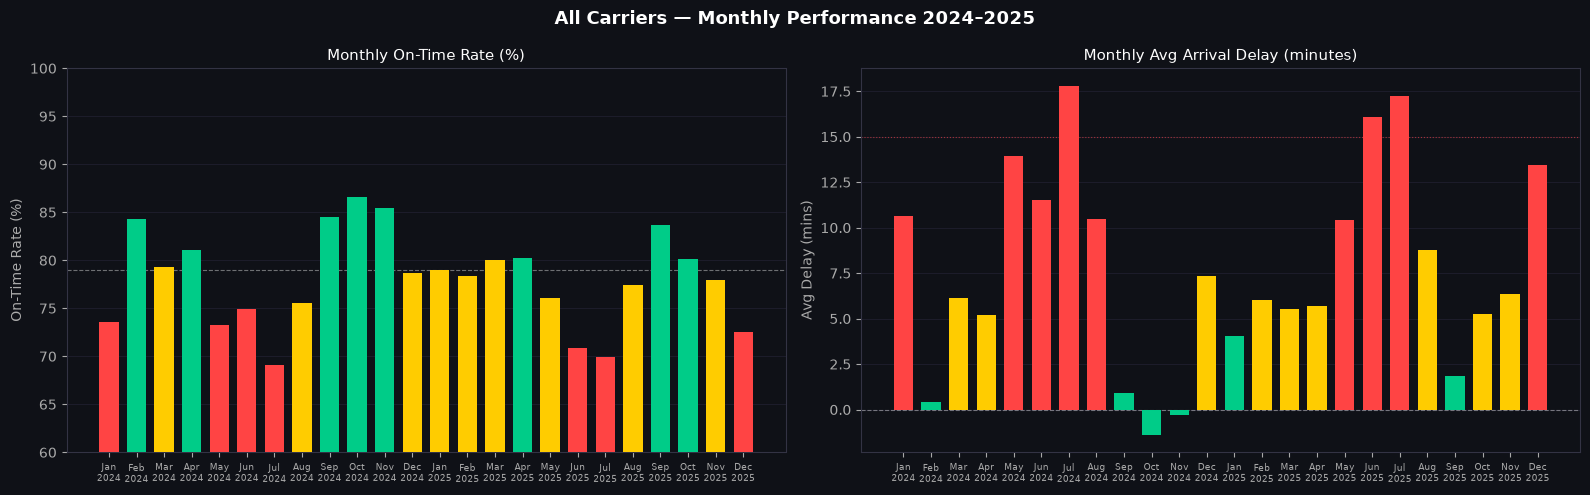

Chart saved.


In [8]:
# Monthly on-time rate chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle('All Carriers — Monthly Performance 2024–2025',
             color=WHITE, fontsize=13, fontweight='bold')

labels = [f"{MONTH_NAMES[int(r['Month'])]}\n{int(r['Year'])}" for _, r in monthly.iterrows()]
x = range(len(monthly))

for ax in axes:
    ax.set_facecolor(BG_COLOR)
    ax.tick_params(colors=TEXT_COLOR)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333344')
    ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.5)

# On-time rate
colors = ['#00cc88' if v >= 80 else '#ffcc00' if v >= 75 else '#ff4444'
          for v in monthly['on_time_rate']]
axes[0].bar(x, monthly['on_time_rate'], color=colors, width=0.7, zorder=3)
axes[0].axhline(79, color=WHITE, linewidth=0.8, linestyle='--', alpha=0.4)
axes[0].set_title('Monthly On-Time Rate (%)', color=WHITE, fontsize=11)
axes[0].set_ylabel('On-Time Rate (%)', color=TEXT_COLOR)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(labels, fontsize=6.5)
axes[0].set_ylim(60, 100)

# Avg delay
delay_colors = ['#00cc88' if v <= 5 else '#ffcc00' if v <= 10 else '#ff4444'
                for v in monthly['avg_delay']]
axes[1].bar(x, monthly['avg_delay'], color=delay_colors, width=0.7, zorder=3)
axes[1].axhline(0,  color=WHITE,   linewidth=0.8, linestyle='--', alpha=0.4)
axes[1].axhline(15, color='#ff4444', linewidth=0.8, linestyle=':', alpha=0.6)
axes[1].set_title('Monthly Avg Arrival Delay (minutes)', color=WHITE, fontsize=11)
axes[1].set_ylabel('Avg Delay (mins)', color=TEXT_COLOR)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(labels, fontsize=6.5)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'week2_fleet_monthly.png'),
            dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()
print('Chart saved.')

---
## Section 5 — Southwest (WN) vs American Airlines (AA)

In [9]:
wn = combined[combined['Carrier'] == 'WN'].copy()
aa = combined[combined['Carrier'] == 'AA'].copy()

def carrier_stats(data):
    operated  = data[data['Cancelled'] == 0]
    late_dep  = operated[operated['DepDelay'] > 0].copy()
    late_dep['made_up'] = late_dep['DepDelay'] - late_dep['ArrDelay']
    return {
        'flights'      : len(data),
        'on_time'      : (operated['ArrDelay'] <= 15).mean() * 100,
        'avg_delay'    : operated['ArrDelay'].mean(),
        'cancel_rate'  : data['Cancelled'].mean() * 100,
        'divert_rate'  : data['Diverted'].mean() * 100,
        'recovery_rate': (late_dep['made_up'] > 0).mean() * 100,
        'cascade_rate' : (data['LateAircraftDelay'].fillna(0) > 0).mean() * 100,
        'unique_tails' : data['TailNumber'].nunique(),
        'unique_routes': (data['Origin']+data['Dest']).nunique(),
    }

wn_s = carrier_stats(wn)
aa_s = carrier_stats(aa)

print(f'{"METRIC":<25} {"WN":>12} {"AA":>12}   WINNER')
print('-'*58)
rows = [
    ('Total flights',     wn_s['flights'],       aa_s['flights'],       '{:>11,.0f}', False),
    ('On-time rate',      wn_s['on_time'],       aa_s['on_time'],       '{:>10.1f}%', True),
    ('Avg arrival delay', wn_s['avg_delay'],     aa_s['avg_delay'],     '{:>10.1f}m', False),
    ('Cancel rate',       wn_s['cancel_rate'],   aa_s['cancel_rate'],   '{:>10.2f}%', False),
    ('Divert rate',       wn_s['divert_rate'],   aa_s['divert_rate'],   '{:>10.3f}%', False),
    ('Recovery rate',     wn_s['recovery_rate'], aa_s['recovery_rate'], '{:>10.1f}%', True),
    ('Cascade leg rate',  wn_s['cascade_rate'],  aa_s['cascade_rate'],  '{:>10.1f}%', False),
    ('Unique aircraft',   wn_s['unique_tails'],  aa_s['unique_tails'],  '{:>11,.0f}', False),
]
for label, wv, av, fmt, higher_better in rows:
    ws = fmt.format(wv)
    as_ = fmt.format(av)
    winner = ('WN' if (wv > av) == higher_better else 'AA') if wv != av else 'TIE'
    print(f'{label:<25} {ws:>12} {as_:>12}   {winner}')

METRIC                              WN           AA   WINNER
----------------------------------------------------------
Total flights                2,811,304    3,903,631   WN
On-time rate                     79.6%        76.8%   WN
Avg arrival delay                 5.6m        11.5m   WN
Cancel rate                      0.84%        1.92%   WN
Divert rate                     0.224%       0.294%   WN
Recovery rate                    77.7%        66.5%   WN
Cascade leg rate                 14.4%        12.9%   AA
Unique aircraft                    895        1,694   WN


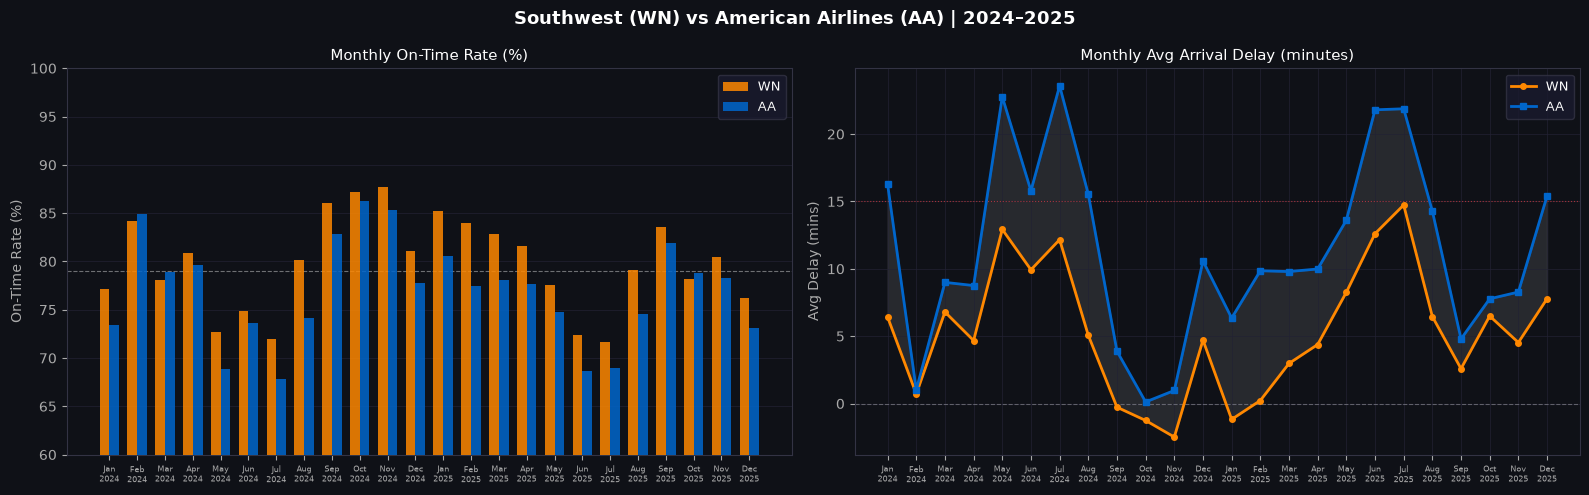

Chart saved.


In [10]:
# WN vs AA comparison chart
def monthly_perf(data):
    op = data[data['Cancelled'] == 0]
    return op.groupby(['Year','Month']).agg(
        on_time_rate = ('ArrDelay', lambda x: (x <= 15).mean() * 100),
        avg_delay    = ('ArrDelay', 'mean'),
    ).reset_index()

wn_m = monthly_perf(wn)
aa_m = monthly_perf(aa)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle('Southwest (WN) vs American Airlines (AA) | 2024–2025',
             color=WHITE, fontsize=13, fontweight='bold')

x = np.arange(len(wn_m))
labels = [f"{MONTH_NAMES[int(r['Month'])]}\n{int(r['Year'])}" for _, r in wn_m.iterrows()]
w = 0.35

for ax in axes:
    ax.set_facecolor(BG_COLOR)
    ax.tick_params(colors=TEXT_COLOR)
    for spine in ax.spines.values(): spine.set_edgecolor('#333344')
    ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.5)

axes[0].bar(x - w/2, wn_m['on_time_rate'], w, color=COLOR_WN, alpha=0.85, label='WN', zorder=3)
axes[0].bar(x + w/2, aa_m['on_time_rate'], w, color=COLOR_AA, alpha=0.85, label='AA', zorder=3)
axes[0].axhline(79, color=WHITE, linewidth=0.8, linestyle='--', alpha=0.4)
axes[0].set_title('Monthly On-Time Rate (%)', color=WHITE, fontsize=11)
axes[0].set_ylabel('On-Time Rate (%)', color=TEXT_COLOR)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, fontsize=6)
axes[0].set_ylim(60, 100)
axes[0].legend(facecolor='#1a1a2e', edgecolor='#333344', labelcolor=WHITE, fontsize=9)

axes[1].plot(x, wn_m['avg_delay'], color=COLOR_WN, linewidth=2,
             marker='o', markersize=4, label='WN', zorder=3)
axes[1].plot(x, aa_m['avg_delay'], color=COLOR_AA, linewidth=2,
             marker='s', markersize=4, label='AA', zorder=3)
axes[1].fill_between(x, wn_m['avg_delay'], aa_m['avg_delay'], alpha=0.1, color=WHITE)
axes[1].axhline(0,  color=WHITE,     linewidth=0.8, linestyle='--', alpha=0.3)
axes[1].axhline(15, color='#ff4444', linewidth=0.8, linestyle=':', alpha=0.6)
axes[1].set_title('Monthly Avg Arrival Delay (minutes)', color=WHITE, fontsize=11)
axes[1].set_ylabel('Avg Delay (mins)', color=TEXT_COLOR)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels, fontsize=6)
axes[1].legend(facecolor='#1a1a2e', edgecolor='#333344', labelcolor=WHITE, fontsize=9)
axes[1].xaxis.grid(True, color=GRID_COLOR, linewidth=0.5)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'week2_wn_vs_aa.png'),
            dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()
print('Chart saved.')

---
## Section 6 — Key Findings

### Pipeline

The three-stage pipeline successfully automated the full workflow from BTS download to clean analysis-ready dataset:

- **24 months downloaded automatically** (2024 + 2025) with zero manual intervention beyond entering the year
- **Smart skip logic** ensures already-processed files are never re-downloaded or re-processed — the pipeline is truly incremental
- **15.3M flights** cleaned and standardised from 120 raw columns to 15 curated fields
- **Repeatable** — running on any new year requires only entering the year at the prompt

### Seasonal Patterns (All Carriers)

Both 2024 and 2025 show the same structural pattern:

| Period | On-Time Rate | Avg Delay | Reason |
|---|---|---|---|
| Jan–Apr | ~79–84% | Low | Post-holiday, light demand |
| May | Drops | Rises | Summer travel begins |
| Jun–Jul | ~69–70% | +17m | Peak summer — worst months |
| Sep–Oct | ~84–87% | Near 0 | Best months of the year |
| Nov–Dec | Mixed | Rises | Holiday disruption |

This pattern is consistent across both years, suggesting it is structural rather than year-specific.

### Southwest vs American Airlines (2024–2025)

Southwest outperforms American on 5 of 6 operational metrics:

| Metric | Southwest (WN) | American (AA) | Winner |
|---|---|---|---|
| On-time rate | 79.6% | 76.8% | **WN** |
| Avg arrival delay | 5.6m | 11.5m | **WN** |
| Cancellation rate | 0.84% | 1.92% | **WN** |
| Diversion rate | 0.22% | 0.29% | **WN** |
| Recovery rate | 77.7% | 66.5% | **WN** |
| Cascade leg rate | 14.4% | 12.9% | AA |

**The cascade rate difference** is analytically significant. Southwest's higher cascade rate (14.4% vs 12.9%) reflects its point-to-point network model — a single delay propagates through the rotation because there is no hub buffer to absorb it. American's hub-and-spoke model concentrates delays at hubs where they can be partially absorbed before affecting downstream flights.

**The recovery rate gap** (77.7% vs 66.5%) suggests Southwest builds more schedule buffer into its timetables, giving aircraft more opportunity to make up gate delays in the air.

### Next Steps (Week 3)

- Tail number tracking extended to multi-month analysis (2024–2025)
- Route-level performance comparison between WN and AA on shared city pairs
- LLM integration for natural language querying of the dataset